### Instalación de dependencias del proyecto

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy import ndimage as ndi
from tqdm import tqdm
import math
from skimage import exposure

# Semilla para reproducibilidad
random.seed(50)

import yaml

import sys
from PIL import Image, ImageFile

# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

# Agregar el directorio raíz del proyecto al sys.path para importar módulos personalizados
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
# Cargar la configuración del proyecto desde el archivo YAML
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [3]:
# Descargar el dataset desde Kaggle utilizando la API de Kaggle
!curl -L -o ../data/raw/bone-break-classification-image-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/pkdarabi/bone-break-classification-image-dataset

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0
100 28.44M 100 28.44M   0      0 15.04M      0   00:01   00:01         12.96M


In [4]:
# Definir las rutas para el archivo ZIP y la carpeta de extracción
zip_path = PROJECT_ROOT / config["path"]["raw_data_dir"] / "bone-break-classification-image-dataset.zip"
extract_path = PROJECT_ROOT / config["path"]["raw_data_dir"] / "dataset_fracturas"

if extract_path.exists() and any(extract_path.iterdir()):
    # Si la carpeta de extracción ya existe y no está vacía,
    # asumimos que el dataset ya ha sido extraído
    print(f"El dataset ya existe")
else:
    if not zip_path.exists():
        raise FileNotFoundError(f"El archivo ZIP no se encontró en: {zip_path}")

    if not extract_path.exists():
        extract_path.mkdir(parents=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    # Eliminar el archivo ZIP
    os.remove(zip_path)

El dataset ya existe


# Funciones utiles

In [5]:
# Función para calcular histograma en escala de grises
def calcular_histograma_gray(ruta):
    img = Image.open(ruta).convert("L")
    img_array = np.array(img)

    hist, _ = np.histogram(
        img_array.ravel(),
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist


In [6]:

def visualizar_histogramas_por_categoria(df):
    # Categorías únicas
    categorias = sorted(df["categoria"].unique())

    # Configuración de subplots
    n_categorias = len(categorias)
    columnas = 2
    filas = math.ceil(n_categorias / columnas)

    fig, axes = plt.subplots(filas, columnas, figsize=(16, filas * 4))

    # Aplanamos axes para recorrerlo fácil
    axes = axes.flatten()

    # Eje X: niveles de intensidad 0-255
    niveles_intensidad = np.arange(256)

    for i, categoria in enumerate(categorias):
        rutas_categoria = df[df["categoria"] == categoria]["ruta"]

        histogramas_categoria = []

        for ruta_relativa in rutas_categoria:
            ruta_absoluta = PROJECT_ROOT / ruta_relativa
            hist = calcular_histograma_gray(ruta_absoluta)
            histogramas_categoria.append(hist)

        hist_promedio = np.array(histogramas_categoria).mean(axis=0)

        axes[i].bar(niveles_intensidad, hist_promedio, width=3.0)
        axes[i].set_title(categoria)
        axes[i].set_xlabel("Nivel de intensidad")
        axes[i].set_ylabel("Frecuencia promedio")
        axes[i].set_xlim(-0.5, 255.5)
        axes[i].set_ylim(0, hist_promedio.max() * 1.1)
        axes[i].grid(True, alpha=0.3)

    # Ocultar subplots vacíos si sobran
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Histogramas promedio por categoría", fontsize=18)
    plt.tight_layout()
    plt.show()

### Visualizacion de la estructura de las carpetas del dataset

Inspeccion de la distribucion y estructura del dataset

In [7]:
def mostrar_estructura(ruta: Path, nivel_max=4):
    for root, dirs, files in os.walk(ruta):
        nivel = root.replace(str(ruta), "").count(os.sep)

        if nivel > nivel_max:
            continue

        indentacion = "    " * nivel
        nombre_carpeta = os.path.basename(root)

        imagenes = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
        ]

        print(f"{indentacion}{nombre_carpeta}/  ({len(imagenes)} imágenes)")

mostrar_estructura(extract_path, nivel_max=5)

dataset_fracturas/  (0 imágenes)
    Bone Break Classification/  (0 imágenes)
        Bone Break Classification/  (0 imágenes)
            Avulsion fracture/  (0 imágenes)
                Test/  (14 imágenes)
                Train/  (109 imágenes)
            Comminuted fracture/  (0 imágenes)
                Test/  (14 imágenes)
                Train/  (134 imágenes)
            Fracture Dislocation/  (0 imágenes)
                Test/  (19 imágenes)
                Train/  (137 imágenes)
            Greenstick fracture/  (0 imágenes)
                Test/  (16 imágenes)
                Train/  (106 imágenes)
            Hairline Fracture/  (0 imágenes)
                Test/  (10 imágenes)
                Train/  (101 imágenes)
            Impacted fracture/  (0 imágenes)
                Test/  (9 imágenes)
                Train/  (75 imágenes)
            Longitudinal fracture/  (0 imágenes)
                Test/  (12 imágenes)
                Train/  (68 imágenes)
            Obliqu

### Crear DataFrame con información de cada imagen

In [8]:
extensiones_img = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

rutas_imagenes = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(extensiones_img):
            rutas_imagenes.append(Path(root) / file)

print("Total de imágenes encontradas:", len(rutas_imagenes))

Total de imágenes encontradas: 1129


In [9]:
datos = []

for ruta in rutas_imagenes:
    partes = ruta.parts

    categoria = ruta.parent.parent.name
    split = ruta.parent.name

    try:
        img = Image.open(ruta)

        ancho, alto = img.size
        modo = img.mode

        img_array = np.array(img)

        # Convertimos a escala de grises solo para estadísticas
        img_gray = img.convert("L")
        gray_array = np.array(img_gray)

        # Verificar si visualmente es gris aunque esté guardada como RGB
        if img_array.ndim == 3 and img_array.shape[2] >= 3:
            es_gris_visual = np.allclose(img_array[:, :, 0], img_array[:, :, 1]) and \
                             np.allclose(img_array[:, :, 1], img_array[:, :, 2])
        else:
            es_gris_visual = True

        ruta_relativa = ruta.relative_to(PROJECT_ROOT)

        datos.append({
            "ruta": str(ruta_relativa),
            "archivo": ruta.name,
            "categoria": categoria,
            "split": split,
            "ancho": ancho,
            "alto": alto,
            "pixeles_totales": ancho * alto,
            "relacion_aspecto": ancho / alto,
            "modo": modo,
            "es_gris_visual": es_gris_visual,
            "intensidad_min": gray_array.min(),
            "intensidad_max": gray_array.max(),
            "intensidad_media": gray_array.mean(),
            "intensidad_std": gray_array.std()
        })

    except Exception as e:
        print("Error leyendo:", ruta)
        print(e)

df = pd.DataFrame(datos)

df.head()

,ruta,archivo,categoria,split,ancho,alto,pixeles_totales,relacion_aspecto,modo,es_gris_visual,intensidad_min,intensidad_max,intensidad_media,intensidad_std
0,data/raw/dataset_fracturas/Bone Break Classifi...,000002_png.rf.c3e00ebc2db78bc94e644c3f6605dad0...,Avulsion fracture,Test,640,640,409600,1.000000,RGB,True,38,228,149.882522,30.616164
1,data/raw/dataset_fracturas/Bone Break Classifi...,05cc2e0302957e0ad27edb6b9ffbc2_jumbo_jpg.rf.c1...,Avulsion fracture,Test,640,640,409600,1.000000,RGB,True,0,250,46.023774,57.114264
2,data/raw/dataset_fracturas/Bone Break Classifi...,1-s2-0-S0899707114002836-gr2_jpg.rf.bb8ed4dee8...,Avulsion fracture,Test,351,526,184626,0.667300,RGB,True,0,255,75.579008,48.063471
3,data/raw/dataset_fracturas/Bone Break Classifi...,13256_2019_2325_Fig1_HTML_png.rf.09368fddb2da3...,Avulsion fracture,Test,286,603,172458,0.474295,RGB,True,0,255,134.934981,54.742886
4,data/raw/dataset_fracturas/Bone Break Classifi...,13256_2019_2325_Fig1_HTML_png.rf.09368fddb2da3...,Avulsion fracture,Test,219,378,82782,0.579365,RGB,True,0,255,119.130125,55.926034


In [10]:
df.shape

(1129, 14)

### Visualización de histograma de intensidad media para identificar posibles outliers

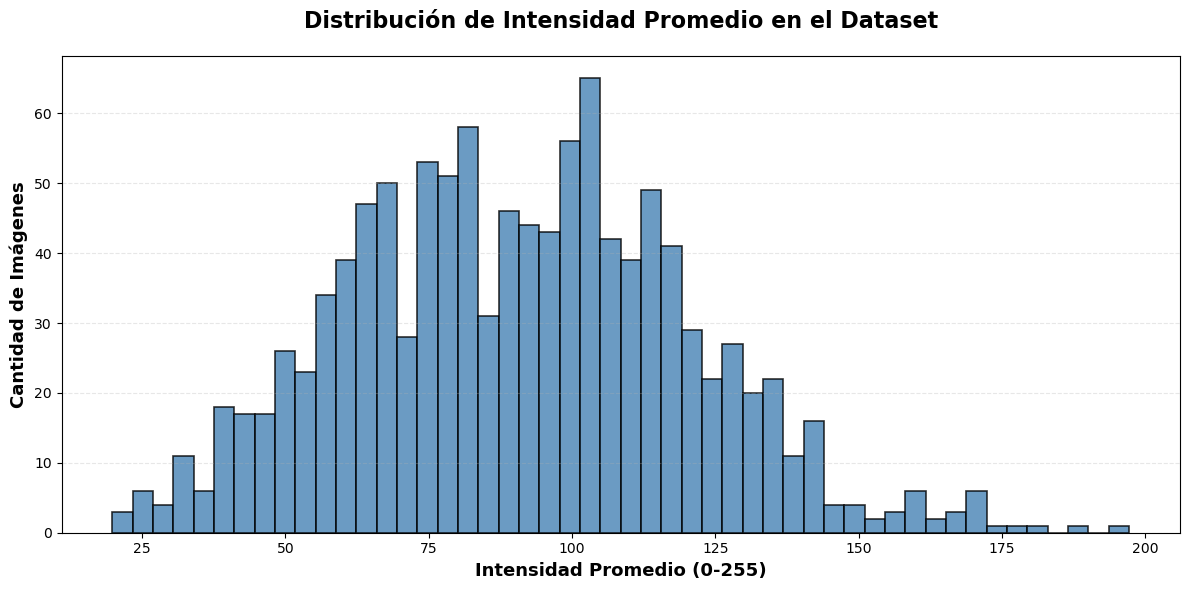

In [11]:
plt.figure(figsize=(12, 6))

plt.hist(df["intensidad_media"], bins=50, color='steelblue', edgecolor='black', alpha=0.8, linewidth=1.2)

plt.title("Distribución de Intensidad Promedio en el Dataset", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Intensidad Promedio (0-255)", fontsize=13, fontweight='bold')
plt.ylabel("Cantidad de Imágenes", fontsize=13, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()

plt.show()

Podemos observar mediante el histograma que presentamos valores outliers con una intensidad media mayor a 170 que puede sugerir un indicio de imagen quemada o corrompida.

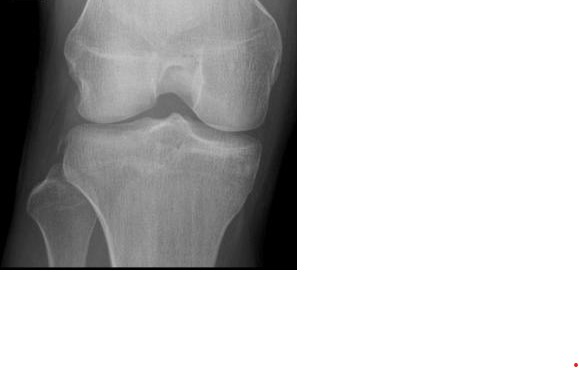

In [12]:
# Visualizamos una imagen con alta intensidad media para verificar su apariencia
img = Image.open(PROJECT_ROOT / df[df["intensidad_media"] > 165].sort_values("intensidad_media", ascending=False).iloc[0]["ruta"])
img

In [13]:
# En base a la visualizacion de la imagen anterior decidimos dropear las
# imagenes con una intensidad media mayor a 165, ya que parecen ser imágenes
# con un fondo muy blanco o sobreexpuestas, lo que podría afectar negativamente el rendimiento del modelo.
df = df[df["intensidad_media"] < 165]

In [14]:
df.shape

(1115, 14)

In [15]:
categorias = df["categoria"].unique().tolist()
categorias

['Avulsion fracture',
 'Comminuted fracture',
 'Fracture Dislocation',
 'Greenstick fracture',
 'Hairline Fracture',
 'Impacted fracture',
 'Longitudinal fracture',
 'Oblique fracture',
 'Pathological fracture',
 'Spiral Fracture']

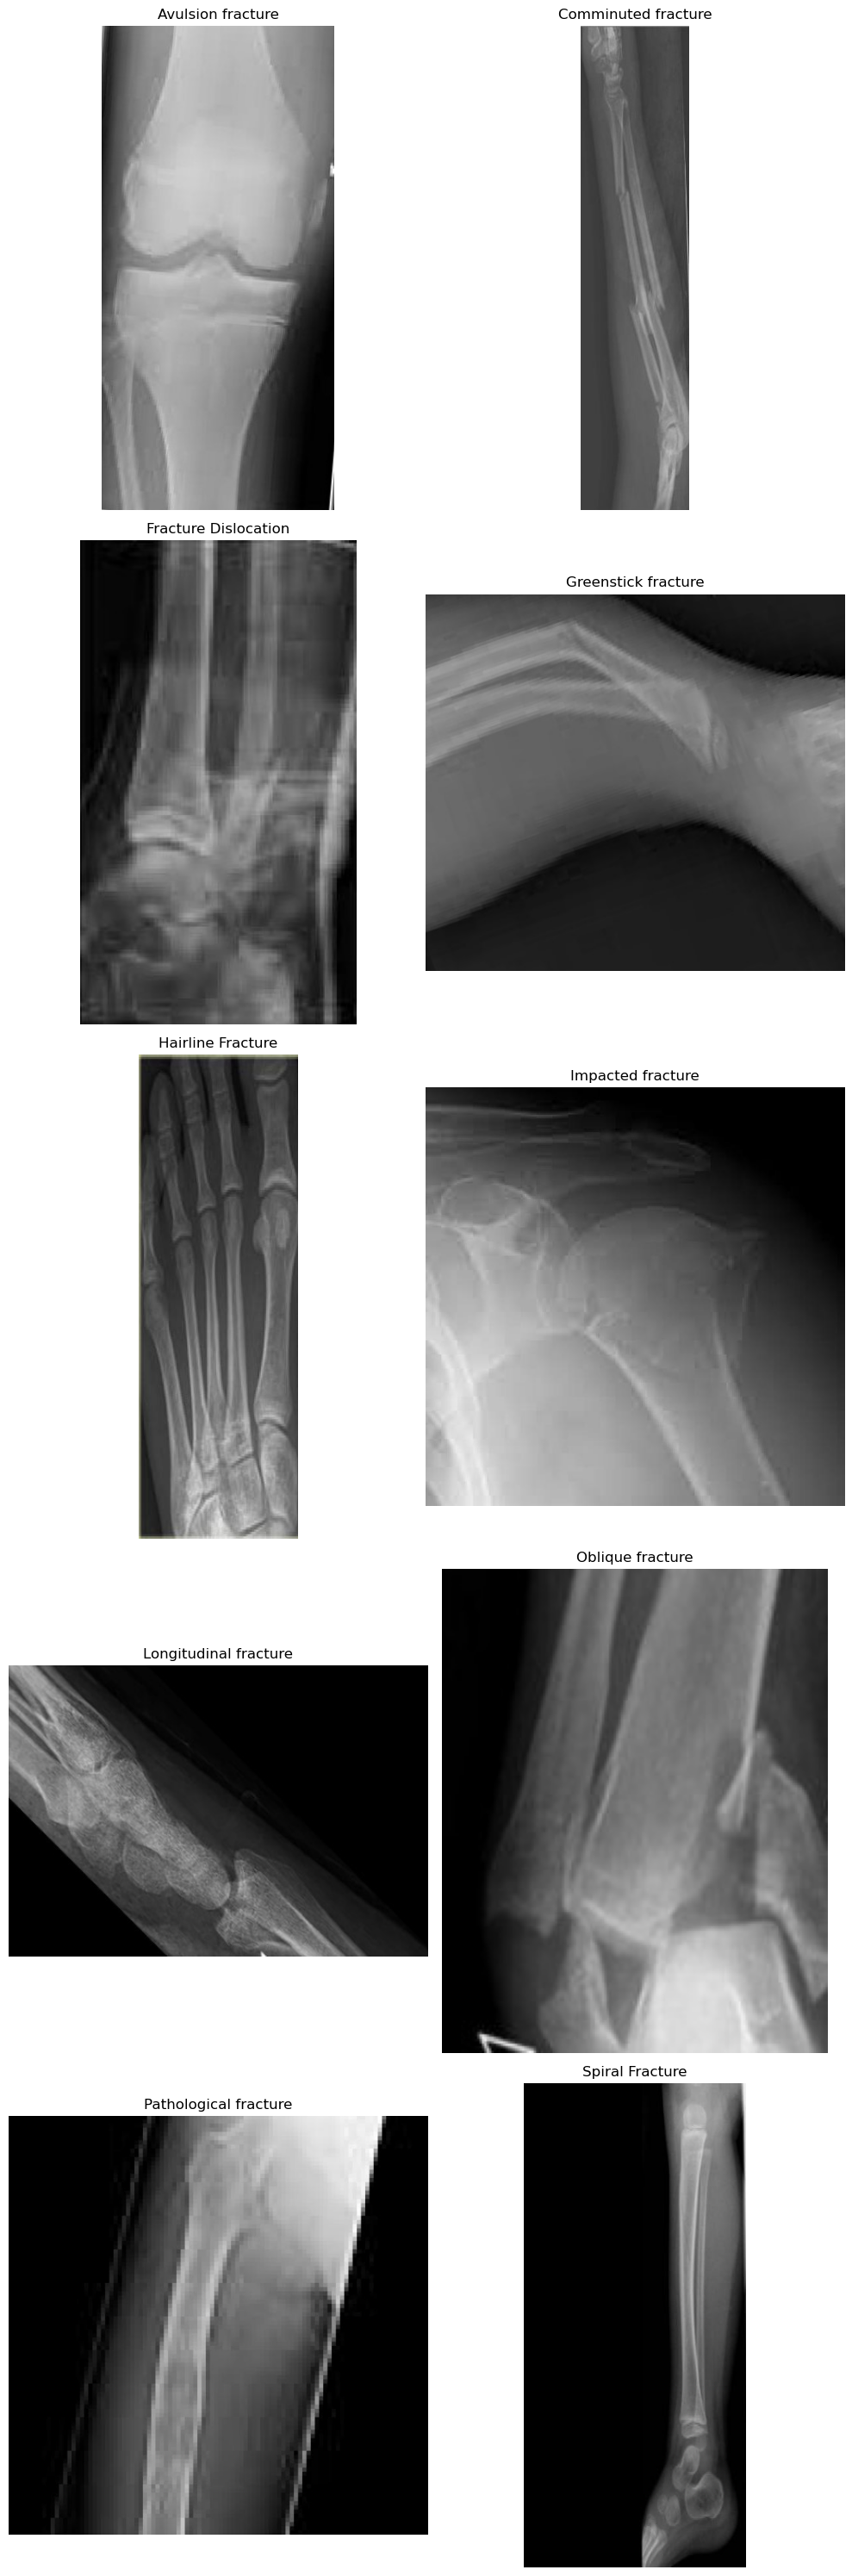

In [16]:
n_cols = 2
n_rows = len(categorias) // n_cols + (len(categorias) % n_cols > 0)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 6*n_rows))
ax = ax.flatten()

for i, categoria in enumerate(categorias):
    cantidad_categoria = df[df["categoria"] == categoria].shape[0]

    random_idx = random.randint(0, cantidad_categoria - 1)

    ruta_imagen_categoria = PROJECT_ROOT / df[df["categoria"] == categoria].iloc[random_idx]["ruta"]

    img = Image.open(ruta_imagen_categoria)

    ax[i].imshow(img)
    ax[i].set_title(categoria)
    ax[i].axis("off")

for j in range(len(categorias), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

### Eliminación de ciertas clases al dataset

Debido a que algumas clases presentan fracturas muy dificiles de ver a simple viste o requiran modelos muy avanzados seran descartados del dataset. En este caso se descartaran las clases de Hairline Fracture y Avulsion Fracture

In [17]:
df = df[~df["categoria"].isin(["Avulsion fracture", "Hairline Fracture"])]

**Punto 1: Tamaño de las imágenes**



In [18]:
#Resumen estadístico
df[["ancho", "alto", "pixeles_totales", "relacion_aspecto"]].describe().round(2)

,ancho,alto,pixeles_totales,relacion_aspecto
count,884.00,884.00,884.00,884.00
mean,438.23,565.78,255256.10,0.83
std,197.64,131.51,137167.26,0.55
min,76.00,95.00,9595.00,0.14
25%,253.75,560.75,130726.50,0.46
50%,474.00,640.00,220635.50,0.89
75%,640.00,640.00,409600.00,1.00
max,640.00,640.00,409600.00,5.82


In [19]:
#Tamaños más frecuentes
tamanios = df.groupby(["ancho", "alto"]).size().reset_index(name="cantidad")
tamanios = tamanios.sort_values("cantidad", ascending=False)

tamanios.head(20)

,ancho,alto,cantidad
491,640,640,324
260,291,640,4
486,640,590,4
48,150,640,3
312,329,640,3
298,316,640,3
231,277,640,3
241,282,640,3
252,286,640,3
60,163,640,3


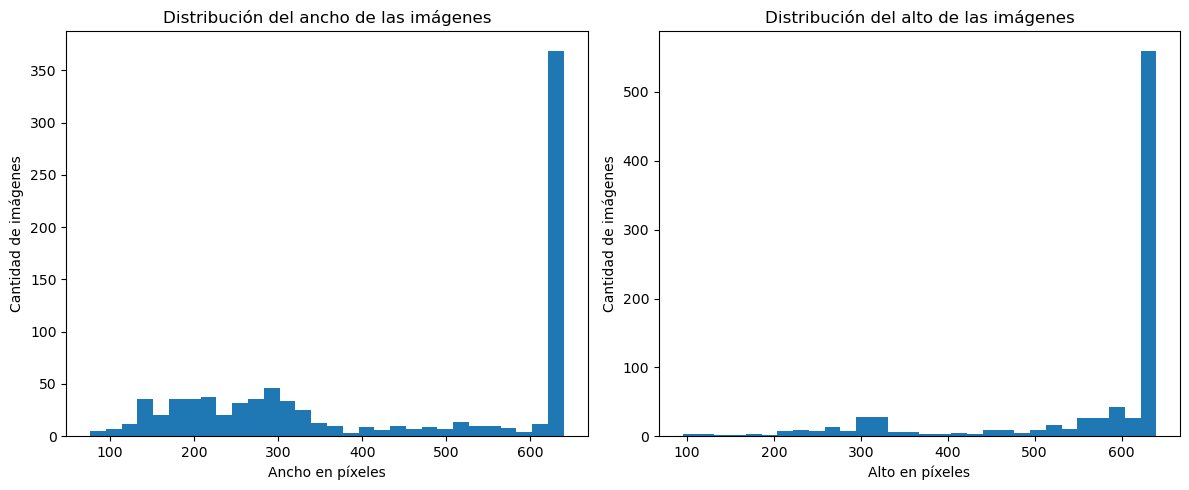

In [20]:
#Gráfico de distribución de ancho y alto
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["ancho"], bins=30)
plt.title("Distribución del ancho de las imágenes")
plt.xlabel("Ancho en píxeles")
plt.ylabel("Cantidad de imágenes")

plt.subplot(1, 2, 2)
plt.hist(df["alto"], bins=30)
plt.title("Distribución del alto de las imágenes")
plt.xlabel("Alto en píxeles")
plt.ylabel("Cantidad de imágenes")

plt.tight_layout()
plt.show()

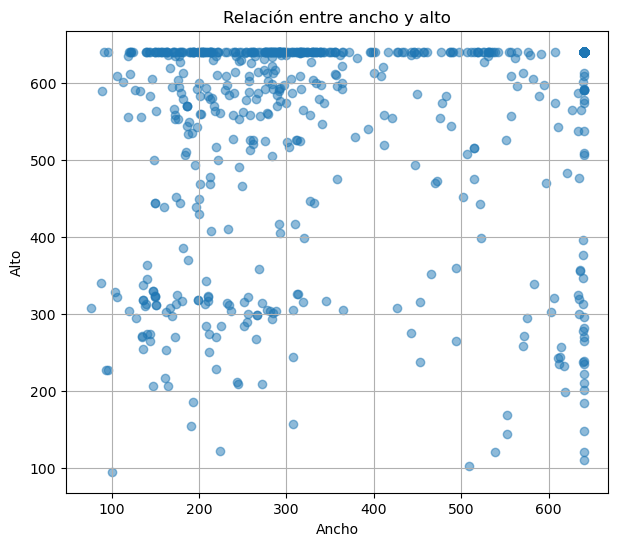

In [21]:
#Relación ancho vs alto
plt.figure(figsize=(7, 6))
plt.scatter(df["ancho"], df["alto"], alpha=0.5)
plt.title("Relación entre ancho y alto")
plt.xlabel("Ancho")
plt.ylabel("Alto")
plt.grid(True)
plt.show()

### **Distribución de categorías de las imágenes**

In [22]:
#Conteo por categoría
conteo_categorias = df["categoria"].value_counts().sort_values(ascending=False)

conteo_categorias

categoria
Fracture Dislocation     153
Comminuted fracture      145
Pathological fracture    133
Greenstick fracture      120
Oblique fracture          85
Spiral Fracture           85
Impacted fracture         83
Longitudinal fracture     80
Name: count, dtype: int64

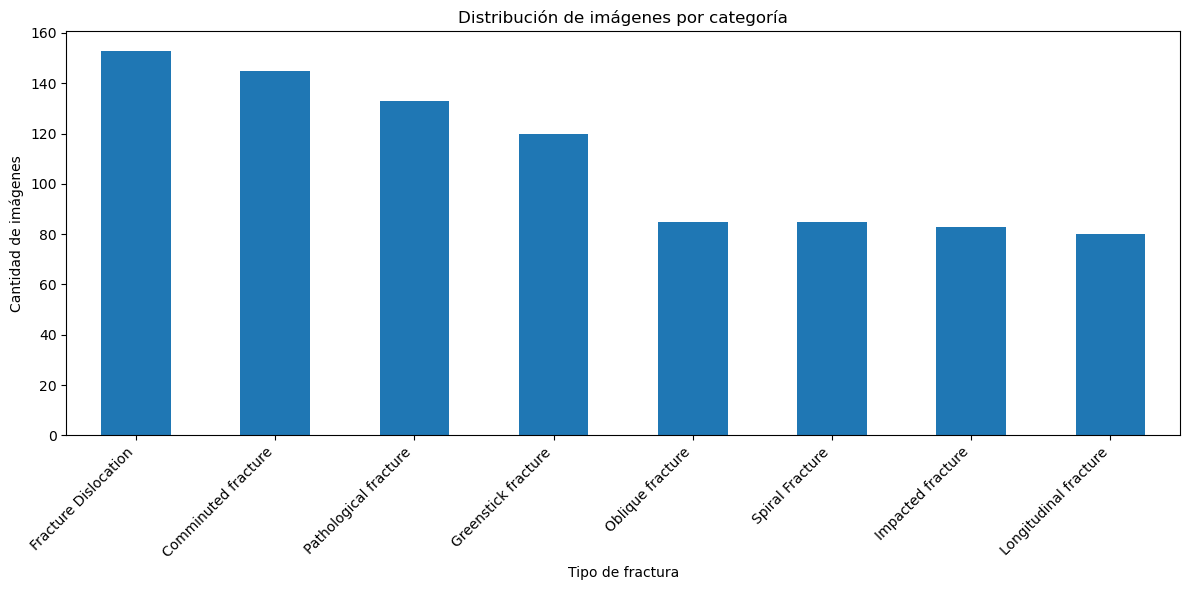

In [23]:
#Gráfico de barras por categoría
plt.figure(figsize=(12, 6))
conteo_categorias.plot(kind="bar")
plt.title("Distribución de imágenes por categoría")
plt.xlabel("Tipo de fractura")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
#Conteo por categoría y split
tabla_categoria_split = pd.crosstab(df["categoria"], df["split"])

tabla_categoria_split

split,Test,Train
categoria,,
Comminuted fracture,13,132
Fracture Dislocation,19,134
Greenstick fracture,16,104
Impacted fracture,9,74
Longitudinal fracture,12,68
Oblique fracture,16,69
Pathological fracture,18,115
Spiral Fracture,12,73


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Tabla de conteo por categoría y split
tabla_categoria_split = pd.crosstab(df["categoria"], df["split"])

# Asegurar orden de columnas si existen
orden_splits = ["Train", "Test"]
tabla_categoria_split = tabla_categoria_split[[col for col in orden_splits if col in tabla_categoria_split.columns]]

# Convertir cada fila a porcentaje
tabla_porcentaje = tabla_categoria_split.div(tabla_categoria_split.sum(axis=1), axis=0) * 100

tabla_porcentaje

split,Train,Test
categoria,,
Comminuted fracture,91.034483,8.965517
Fracture Dislocation,87.581699,12.418301
Greenstick fracture,86.666667,13.333333
Impacted fracture,89.156627,10.843373
Longitudinal fracture,85.000000,15.000000
Oblique fracture,81.176471,18.823529
Pathological fracture,86.466165,13.533835
Spiral Fracture,85.882353,14.117647


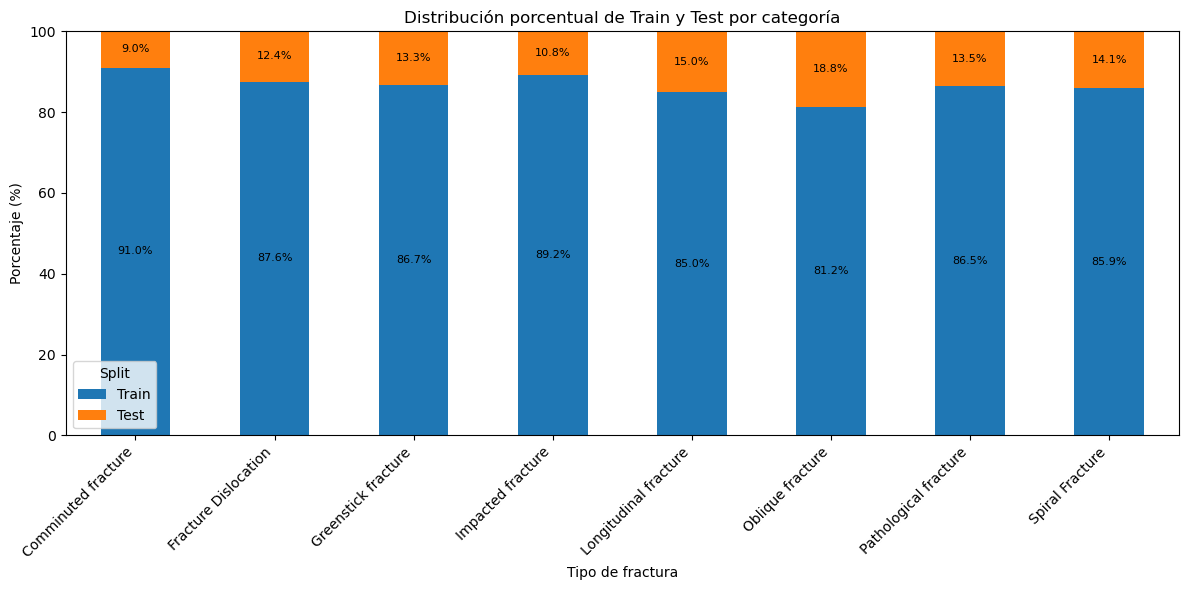

In [26]:
ax = tabla_porcentaje.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribución porcentual de Train y Test por categoría")
plt.xlabel("Tipo de fractura")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.legend(title="Split")

# Agregar etiquetas de porcentaje
for container in ax.containers:
    labels = [
        f"{valor.get_height():.1f}%" if valor.get_height() > 0 else ""
        for valor in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### **Histogramas promedio**

En esta sección visualizaremos los histogramas promedios para posteriormente poder dar un diagnostico a la imagen

In [27]:
# Funciones utiles para análisis de imágenes

def cargar_gris(ruta):
    img = Image.open(ruta).convert("L")
    return np.array(img)

def calcular_histograma_gray(ruta):
    img_gray = cargar_gris(ruta)

    hist, bins = np.histogram(
        img_gray.ravel(),
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist

In [28]:
#Histograma promedio general del dataset
histogramas = []

for ruta_relativa in df["ruta"]:
    ruta_absoluta = PROJECT_ROOT / ruta_relativa
    hist = calcular_histograma_gray(ruta_absoluta)
    histogramas.append(hist)

histogramas = np.array(histogramas)

hist_promedio_general = histogramas.mean(axis=0)

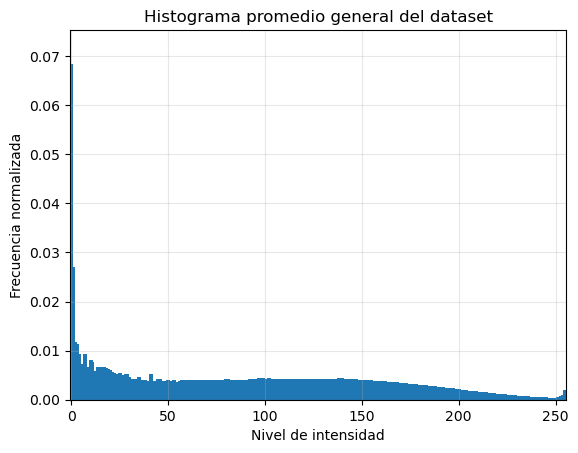

In [29]:
niveles_intensidad = np.arange(256)
plt.bar(niveles_intensidad, hist_promedio_general, width=2.)
plt.title("Histograma promedio general del dataset")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia normalizada")
plt.xlim(-0.5, 255.5)
plt.ylim(0, hist_promedio_general.max() * 1.1)
plt.grid(True, alpha=0.3)

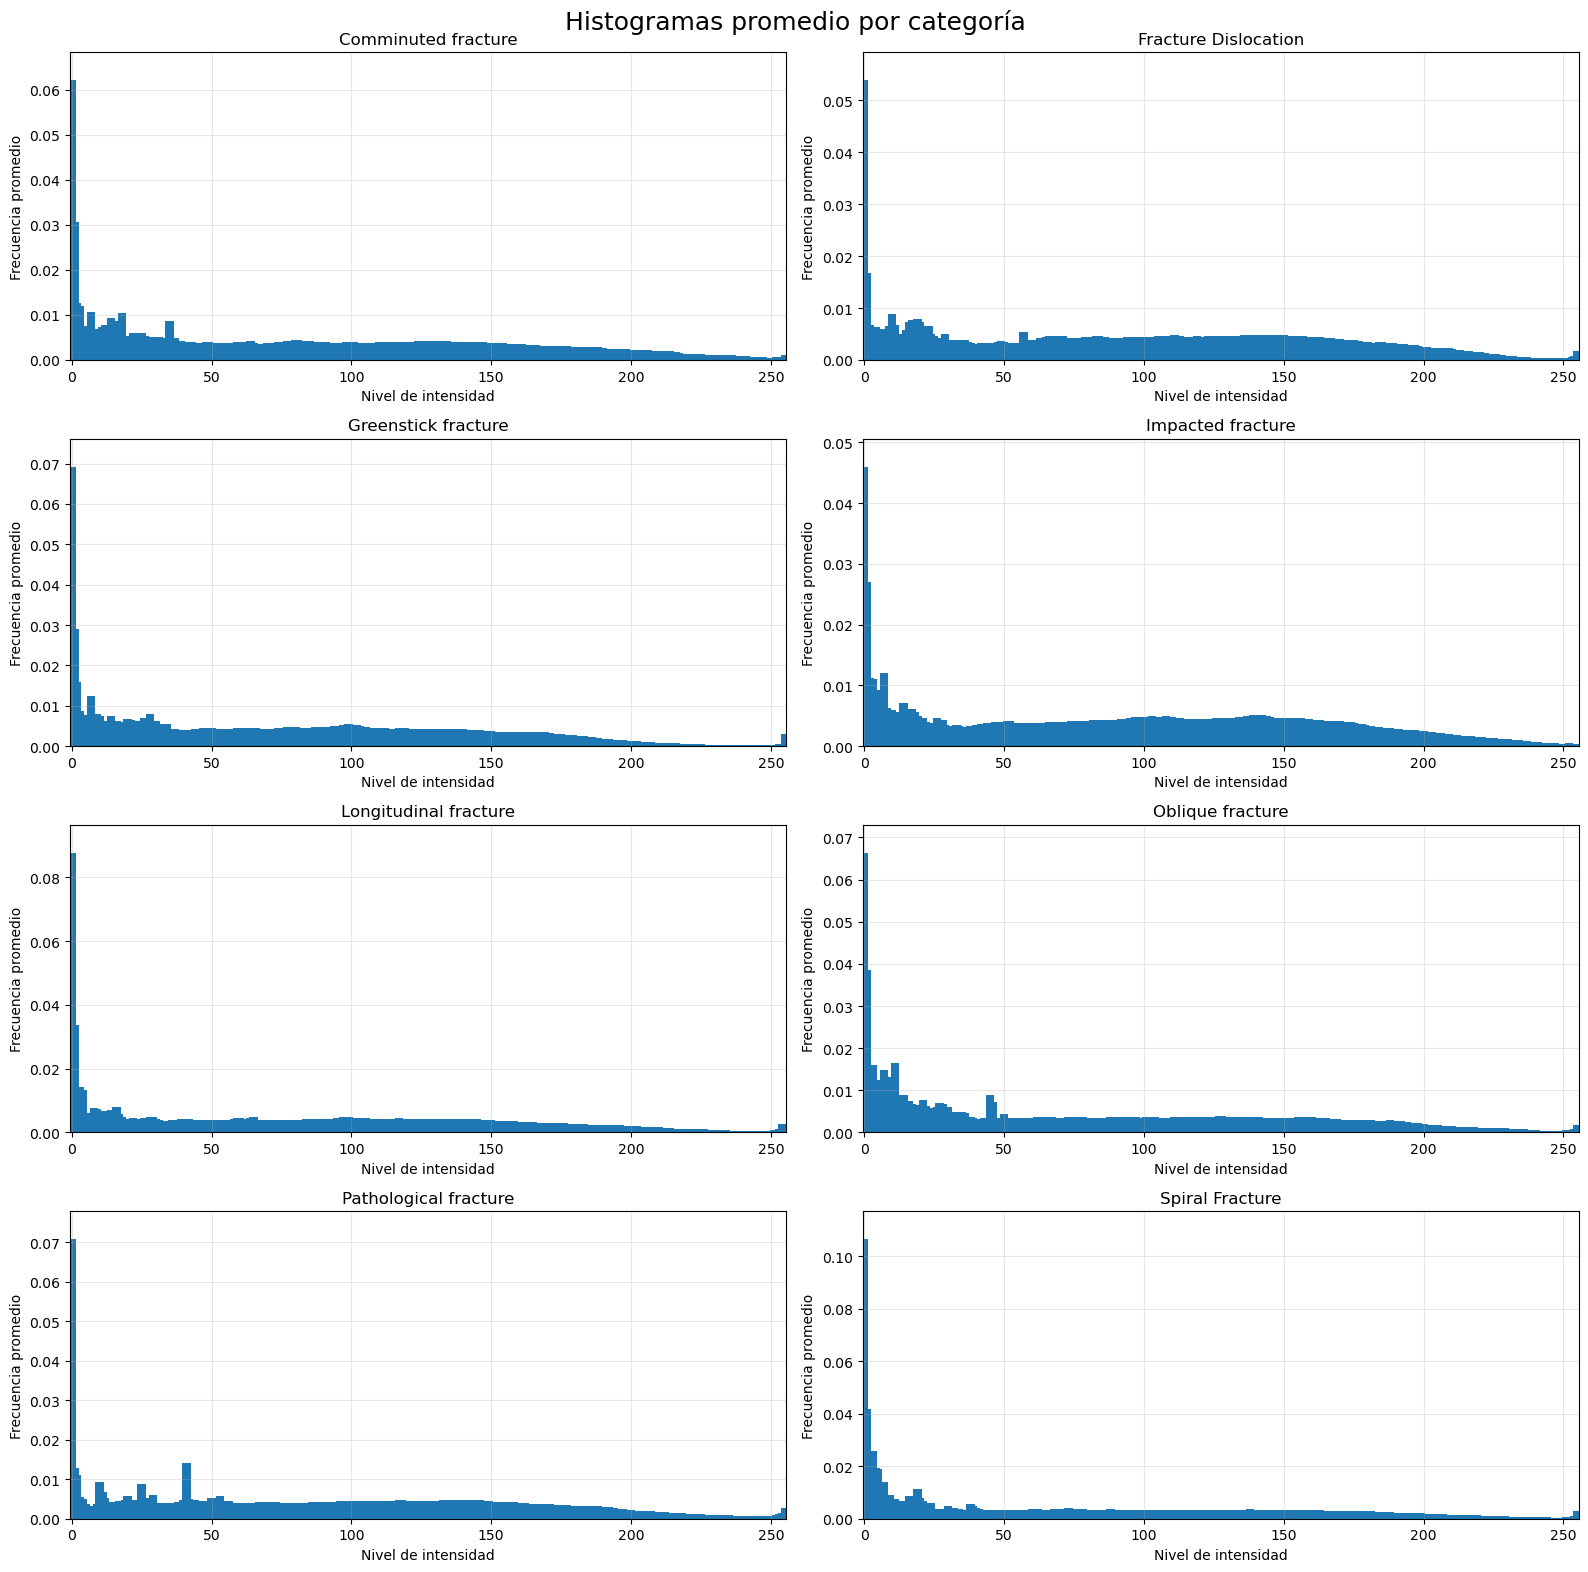

In [30]:
visualizar_histogramas_por_categoria(df)

### **Escala de grises de las imágenes**

In [31]:
#Ver cuántas imágenes son RGB y cuántas parecen grises
df["modo"].value_counts()

modo
RGB    884
Name: count, dtype: int64

In [32]:
df["es_gris_visual"].value_counts()

es_gris_visual
True     634
False    250
Name: count, dtype: int64

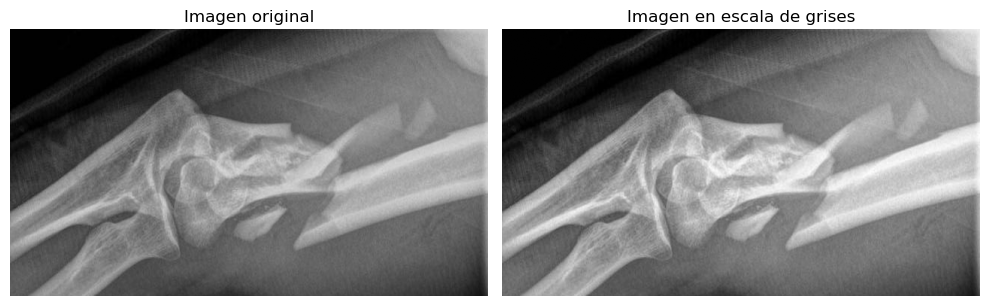

In [33]:
#Mostrar una imagen original y su versión en escala de grises
ruta_ejemplo_relativa = df.iloc[1]["ruta"]
ruta_ejemplo = PROJECT_ROOT / ruta_ejemplo_relativa

img_original = Image.open(ruta_ejemplo)
img_gray = img_original.convert("L")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")

plt.tight_layout()
plt.show()

## Transformaciones y Guardado de Imágenes Transformadas

Aplicaremos el pipeline de transformación a **todas las imágenes** y las guardaremos en `data/processed/` manteniendo la estructura de categorías y splits.

In [34]:
#Crear las funciones de filtros
def transf_lineal(img, a=1.0, b=0):
    img_float = img.astype(float)
    salida = a * img_float + b
    salida = np.clip(salida, 0, 255)
    return np.rint(salida).astype(np.uint8)


def transf_gamma(img, gamma=1.0, c=1.0):

    img_norm = img.astype(float) / 255.0
    salida = c * (img_norm ** gamma)
    salida = salida * 255
    salida = np.clip(salida, 0, 255)
    return np.rint(salida).astype(np.uint8)


def filtro_media(img, k=3):
    kernel = np.ones((k, k)) / (k * k)
    salida = ndi.convolve(img.astype(float), kernel, mode="reflect")
    return np.clip(salida, 0, 255).astype(np.uint8)


def filtro_mediana(img, k=3):
    salida = ndi.median_filter(img, size=k, mode="reflect")
    return salida.astype(np.uint8)


def unsharp(img, sigma=2, k=1.0):
    img_float = img.astype(float)

    img_blur = ndi.gaussian_filter(img_float, sigma=sigma)
    detalle = img_float - img_blur

    salida = img_float + k * detalle
    salida = np.clip(salida, 0, 255)

    return salida.astype(np.uint8)


In [35]:
def preprocessing_pipeline(ruta_imagen, size=320):
    # Cargar imagen en escala de grises
    img = Image.open(ruta_imagen).convert("L")
    
    # Redimensionar a 320x320
    img = img.resize((size, size), Image.Resampling.LANCZOS)
    img_arr = np.array(img).astype(np.uint8)
    
    # Paso 1: Suavizar ruido impulsivo con filtro mediana
    temp = filtro_mediana(img_arr, k=3)
    
    # Paso 2: Mejorar contraste local con CLAHE
    clahe = exposure.equalize_adapthist(
        temp / 255.0,
        clip_limit=0.02
    )
    clahe = np.clip(clahe * 255, 0, 255).astype(np.uint8)
    
    # Paso 3: Resaltar bordes con unsharp masking
    resultado = unsharp(clahe, sigma=1.0, k=0.7)
    
    return resultado

In [36]:
# Configurar ruta de salida para imágenes procesadas
processed_dir = PROJECT_ROOT / config["path"]["processed_data_dir"] / "dataset_fracturas"

print("=" * 70)
print("INICIANDO PREPROCESAMIENTO DE IMÁGENES")
print("=" * 70)

# Crear estructura de carpetas: processed/categoria/split/
for categoria in df["categoria"].unique():
    for split in df["split"].unique():
        carpeta_destino = processed_dir / categoria / split
        carpeta_destino.mkdir(parents=True, exist_ok=True)
        print(f"✓ Carpeta creada: {carpeta_destino.relative_to(PROJECT_ROOT)}")

print("\n" + "=" * 70)
print("PROCESANDO IMÁGENES...")
print("=" * 70 + "\n")

# Variables de seguimiento
procesadas = 0
errores = 0
errores_lista = []

# Procesar cada imagen del DataFrame
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Procesando imágenes"):
    try:
        # Rutas
        ruta_relativa = row["ruta"]
        ruta_original = PROJECT_ROOT / ruta_relativa
        
        categoria = row["categoria"]
        split = row["split"]
        archivo = row["archivo"]
        
        # Ruta de destino
        carpeta_destino = processed_dir / categoria / split
        ruta_destino = carpeta_destino / archivo
        
        # Aplicar pipeline
        img_procesada = preprocessing_pipeline(ruta_original)
        
        # Guardar imagen procesada
        img_pil = Image.fromarray(img_procesada)
        img_pil.save(ruta_destino, quality=95)
        
        procesadas += 1
        
    except Exception as e:
        errores += 1
        errores_lista.append((ruta_relativa, str(e)))
        print(f"✗ Error procesando {ruta_relativa}: {str(e)}")

# Resumen final
print("\n" + "=" * 70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("=" * 70)
print(f"✓ Imágenes procesadas exitosamente: {procesadas}")
print(f"✗ Errores: {errores}")
print(f"Ruta de salida: {processed_dir.relative_to(PROJECT_ROOT)}/")
print("=" * 70)

if errores > 0:
    print("\nDetalles de errores:")
    for ruta, error in errores_lista[:5]:  # Mostrar primeros 5 errores
        print(f"  - {ruta}: {error}")

INICIANDO PREPROCESAMIENTO DE IMÁGENES
✓ Carpeta creada: data/processed/dataset_fracturas/Comminuted fracture/Test
✓ Carpeta creada: data/processed/dataset_fracturas/Comminuted fracture/Train
✓ Carpeta creada: data/processed/dataset_fracturas/Fracture Dislocation/Test
✓ Carpeta creada: data/processed/dataset_fracturas/Fracture Dislocation/Train
✓ Carpeta creada: data/processed/dataset_fracturas/Greenstick fracture/Test
✓ Carpeta creada: data/processed/dataset_fracturas/Greenstick fracture/Train
✓ Carpeta creada: data/processed/dataset_fracturas/Impacted fracture/Test
✓ Carpeta creada: data/processed/dataset_fracturas/Impacted fracture/Train
✓ Carpeta creada: data/processed/dataset_fracturas/Longitudinal fracture/Test
✓ Carpeta creada: data/processed/dataset_fracturas/Longitudinal fracture/Train
✓ Carpeta creada: data/processed/dataset_fracturas/Oblique fracture/Test
✓ Carpeta creada: data/processed/dataset_fracturas/Oblique fracture/Train
✓ Carpeta creada: data/processed/dataset_fractu

Procesando imágenes: 100%|██████████| 884/884 [00:13<00:00, 65.83it/s]


RESUMEN DEL PREPROCESAMIENTO
✓ Imágenes procesadas exitosamente: 884
✗ Errores: 0
Ruta de salida: data/processed/dataset_fracturas/


In [37]:
# Verificar estructura de carpetas creadas
print("\n" + "=" * 70)
print("ESTRUCTURA DE DATOS PROCESADOS")
print("=" * 70 + "\n")

for categoria in sorted(df["categoria"].unique()):
    print(f"{categoria}/")
    for split in sorted(df["split"].unique()):
        carpeta = processed_dir / categoria / split
        if carpeta.exists():
            num_imagenes = len(list(carpeta.glob("*.*")))
            print(f"   ├─ {split}/  ({num_imagenes} imágenes)")

print("\n" + "=" * 70)
print("✓ PREPROCESAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 70)


ESTRUCTURA DE DATOS PROCESADOS

Comminuted fracture/
   ├─ Test/  (13 imágenes)
   ├─ Train/  (132 imágenes)
Fracture Dislocation/
   ├─ Test/  (19 imágenes)
   ├─ Train/  (134 imágenes)
Greenstick fracture/
   ├─ Test/  (16 imágenes)
   ├─ Train/  (104 imágenes)
Impacted fracture/
   ├─ Test/  (9 imágenes)
   ├─ Train/  (74 imágenes)
Longitudinal fracture/
   ├─ Test/  (12 imágenes)
   ├─ Train/  (68 imágenes)
Oblique fracture/
   ├─ Test/  (16 imágenes)
   ├─ Train/  (69 imágenes)
Pathological fracture/
   ├─ Test/  (18 imágenes)
   ├─ Train/  (115 imágenes)
Spiral Fracture/
   ├─ Test/  (12 imágenes)
   ├─ Train/  (73 imágenes)

✓ PREPROCESAMIENTO COMPLETADO EXITOSAMENTE


In [38]:
# Generamos un nuevo DataFrame con las rutas de las imágenes procesadas para futuras referencias
datos_procesados = []
for categoria in df["categoria"].unique():
    for split in df["split"].unique():
        carpeta = processed_dir / categoria / split
        if carpeta.exists():
            for img_file in carpeta.glob("*.*"):
                img_pros = Image.open(img_file)

                gray_array_pros = np.array(img_pros)
                datos_procesados.append({
                    "ruta": str(img_file.relative_to(PROJECT_ROOT)),
                    "categoria": categoria,
                    "split": split,
                    "intensidad_min": gray_array_pros.min(),
                    "intensidad_max": gray_array_pros.max(),
                    "intensidad_media": gray_array_pros.mean(),
                    "intensidad_std": gray_array_pros.std()
                })
df_procesados = pd.DataFrame(datos_procesados)

In [39]:
df_procesados.head()

,ruta,categoria,split,intensidad_min,intensidad_max,intensidad_media,intensidad_std
0,data/processed/dataset_fracturas/Comminuted fr...,Comminuted fracture,Test,0,255,69.325996,57.666476
1,data/processed/dataset_fracturas/Comminuted fr...,Comminuted fracture,Test,0,255,119.592187,59.903223
2,data/processed/dataset_fracturas/Comminuted fr...,Comminuted fracture,Test,0,255,89.437109,71.025734
3,data/processed/dataset_fracturas/Comminuted fr...,Comminuted fracture,Test,0,255,122.995723,56.822188
4,data/processed/dataset_fracturas/Comminuted fr...,Comminuted fracture,Test,0,255,86.620566,62.436468


In [40]:
#Histograma promedio general del dataset
histogramas_pros = []

for ruta_relativa in df_procesados["ruta"]:
    ruta_absoluta = PROJECT_ROOT / ruta_relativa
    hist = calcular_histograma_gray(ruta_absoluta)
    histogramas_pros.append(hist)

histogramas_pros = np.array(histogramas_pros)

hist_promedio_general_pros = histogramas_pros.mean(axis=0)

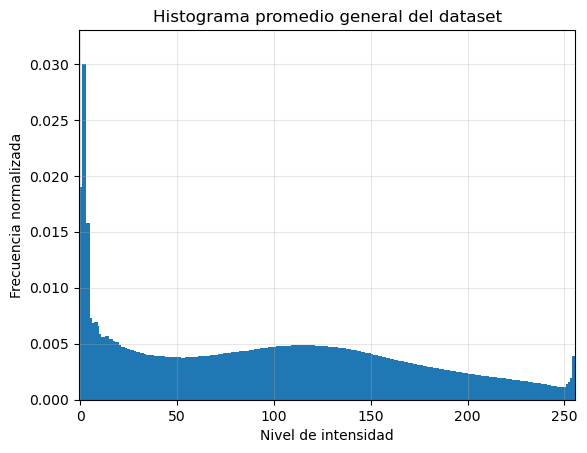

In [41]:
niveles_intensidad = np.arange(256)
plt.bar(niveles_intensidad, hist_promedio_general_pros, width=2.)
plt.title("Histograma promedio general del dataset")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia normalizada")
plt.xlim(-0.5, 255.5)
plt.ylim(0, hist_promedio_general_pros.max() * 1.1)
plt.grid(True, alpha=0.3)

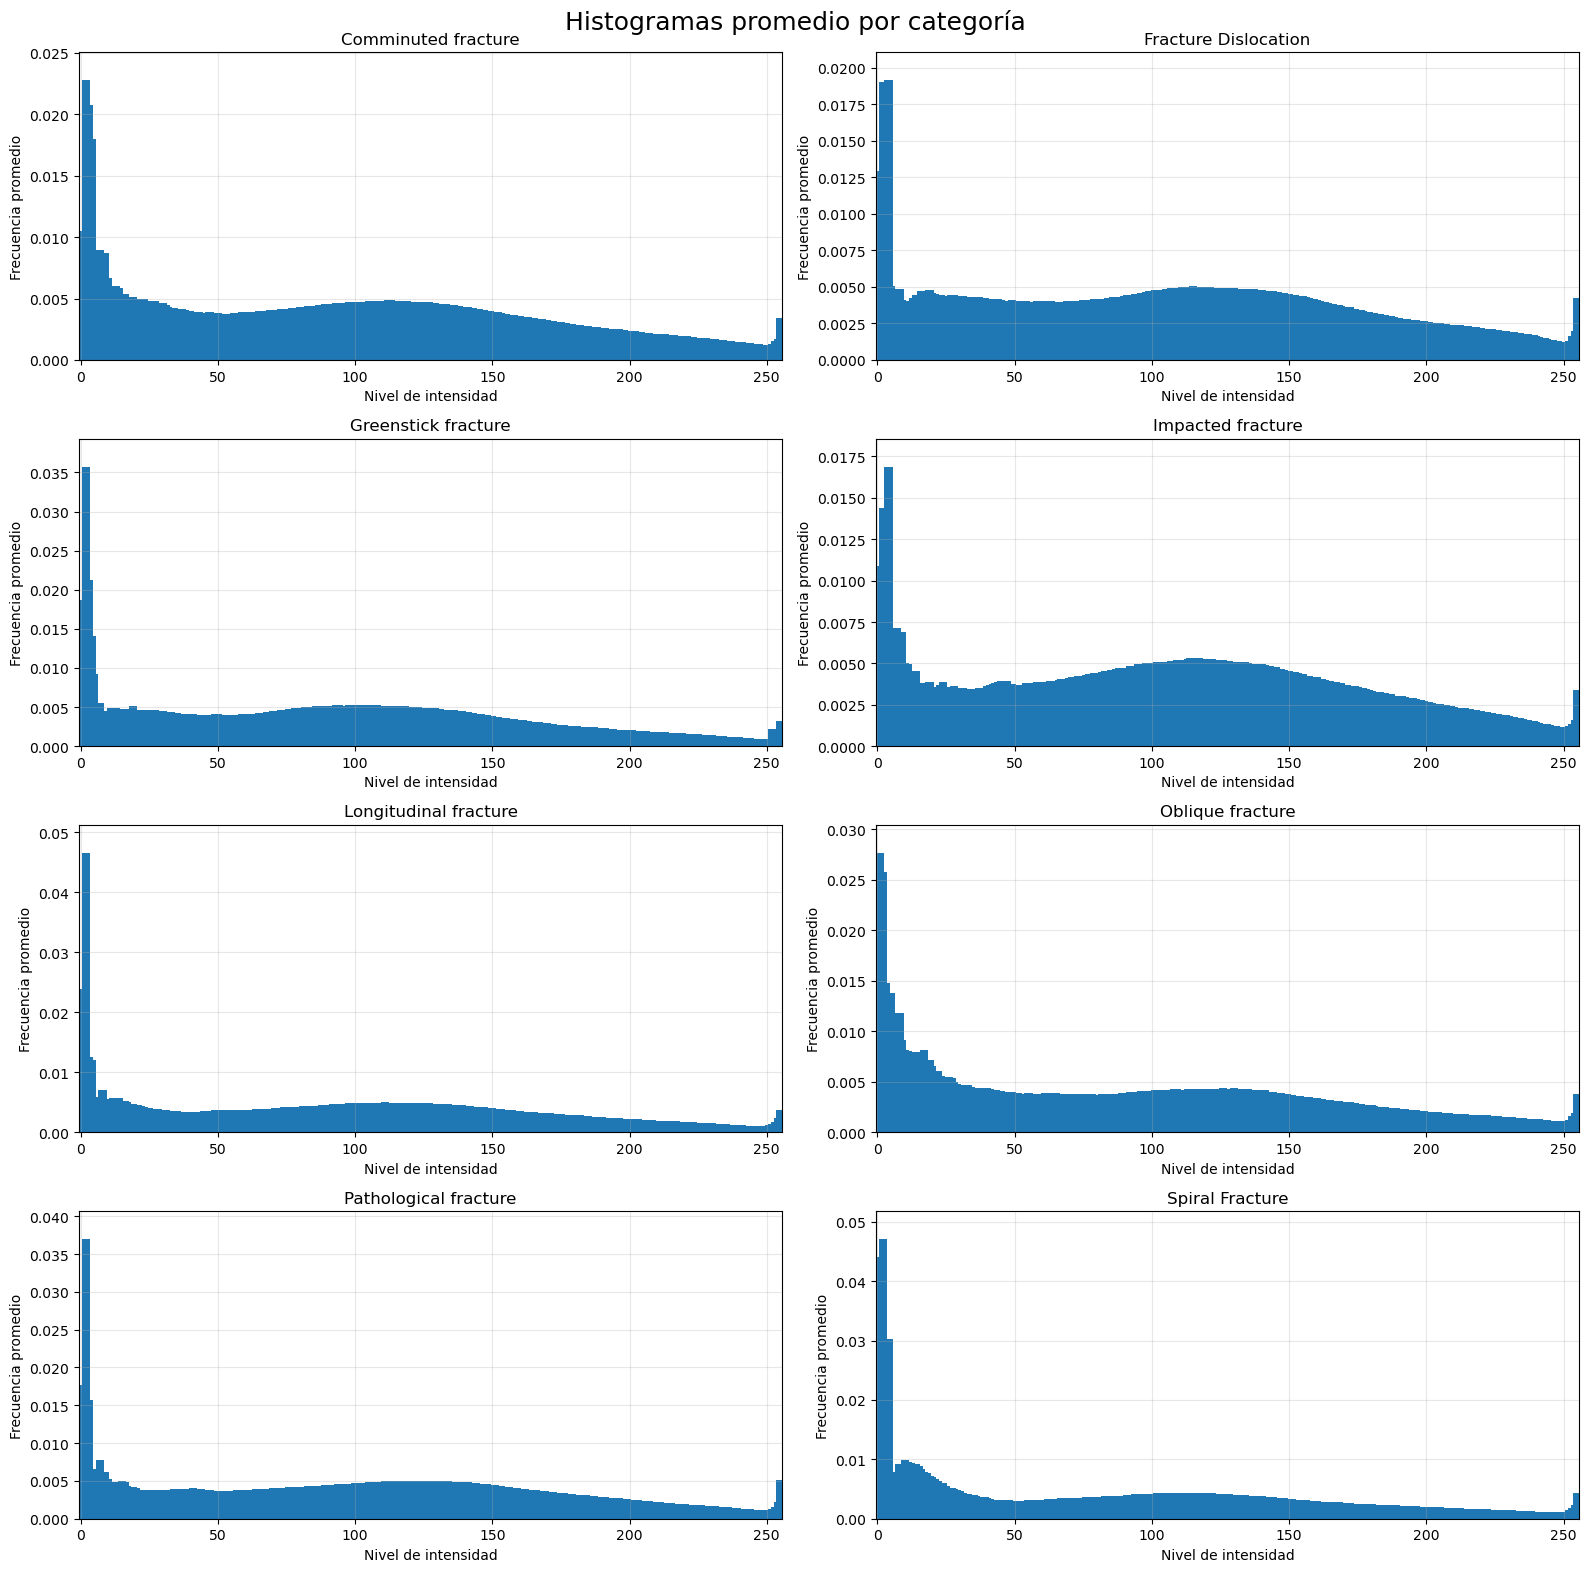

In [42]:
visualizar_histogramas_por_categoria(df_procesados)

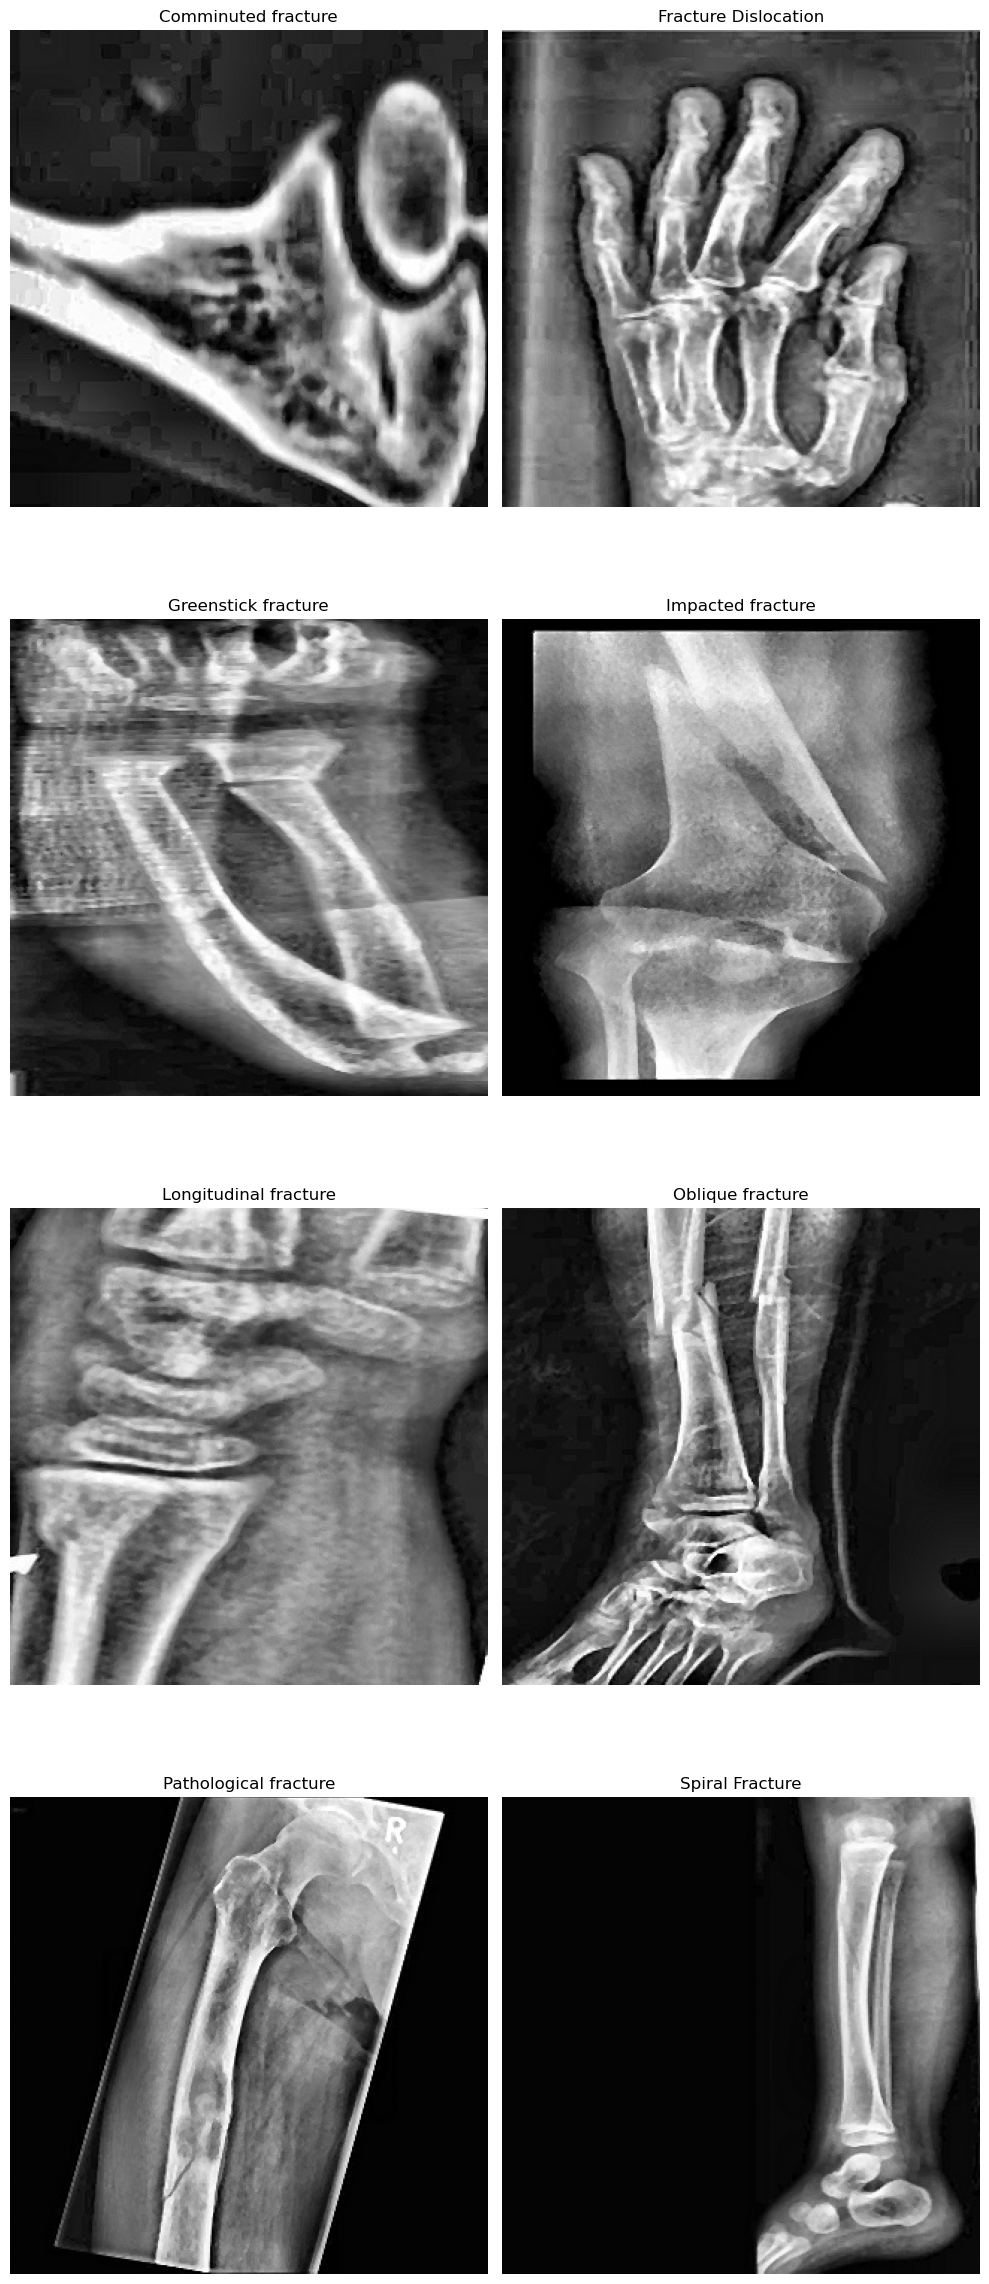

In [43]:
categorias_procesadas = df_procesados["categoria"].unique().tolist()

n_cols = 2
n_rows = len(categorias_procesadas) // n_cols + (len(categorias_procesadas) % n_cols > 0)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 6*n_rows))
ax = ax.flatten()

for i, categoria in enumerate(categorias_procesadas):
    cantidad_categoria = df_procesados[df_procesados["categoria"] == categoria].shape[0]

    ruta_imagen_categoria = PROJECT_ROOT / df_procesados[df_procesados["categoria"] == categoria].iloc[random_idx]["ruta"]

    img = Image.open(ruta_imagen_categoria)

    ax[i].imshow(img, cmap="gray")
    ax[i].set_title(categoria)
    ax[i].axis("off")

for j in range(len(categorias_procesadas), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()